# 8.15 同一份材料，如何依不同要求作答？


仍用書店的四行告示：中文是「今日休館」「明日開放」，英文是「Closed today」「Open tomorrow」。它們依序排成下面的清單。我們不改材料，改的是交給助手的要求。

| 列號 | 語言 | 告示文字 |
| --- | --- | --- |
| 1 | 中文 | 今日休館 |
| 2 | 英文 | Closed today |
| 3 | 中文 | 明日開放 |
| 4 | 英文 | Open tomorrow |

第一個要求是「全部照抄，一行一項，不加列號或說明」。它的理想回答應有四行。第二個要求是「只抄中文，一行一項，不加列號或說明」，理想回答只有第1、3列。兩份回答都使用材料裡的原字句，第二份更短，是因為要求選了較小範圍。

| 輸入中的要求 | 用來教這個要求的回答 |
| --- | --- |
| 全部照抄 | 今日休館<br>Closed today<br>明日開放<br>Open tomorrow |
| 只抄中文 | 今日休館<br>明日開放 |

如果想用示範教模型處理這種差別，一筆資料不能只有告示和一份漂亮的回答。它還要保留這次要求；示範答案也必須執行它。在先前學過的[SFT](https://birdhackor.github.io/tiny-perceptron-vlm/8.3.html)裡，模型看這份前文，練習預測助手的目標回答。若「只抄中文」後面的目標仍寫四行，就在教它遇到這個要求時也抄英文。答案的各句雖然都真實，這筆示範和目標任務仍不一致。

圖中兩個分支共用同一份告示，只在請求和目標答案上有差異。箭頭表示「這個輸入應搭配這份示範」，讓我們對照兩筆資料的安排。


In [1]:
# @title 準備本節的工具（首次執行）
from pathlib import Path
import os
import subprocess
import sys

# Colab 會先下載專案；本機 Jupyter 沿用已開啟的 repo。
try:
    import google.colab
except ImportError:
    in_colab = False
else:
    in_colab = True

if in_colab:
    root = Path("/content/tiny-perceptron-vlm")
    if not root.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/birdhackor/tiny-perceptron-vlm.git", str(root)],
            env={**os.environ, "GIT_LFS_SKIP_SMUDGE": "1"},
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-e", str(root)], check=True)
    os.chdir(root)

root = Path.cwd().resolve()
while not (root / "pyproject.toml").exists() and root != root.parent:
    root = root.parent
if not (root / "tiny_perceptron").is_dir():
    raise RuntimeError("本機請先依 course/first-steps.md 開啟 repo；免安裝練習可使用本節的 Colab 入口")
sys.path.insert(0, str(root))
import torch

torch.set_num_threads(1)
torch.manual_seed(42)

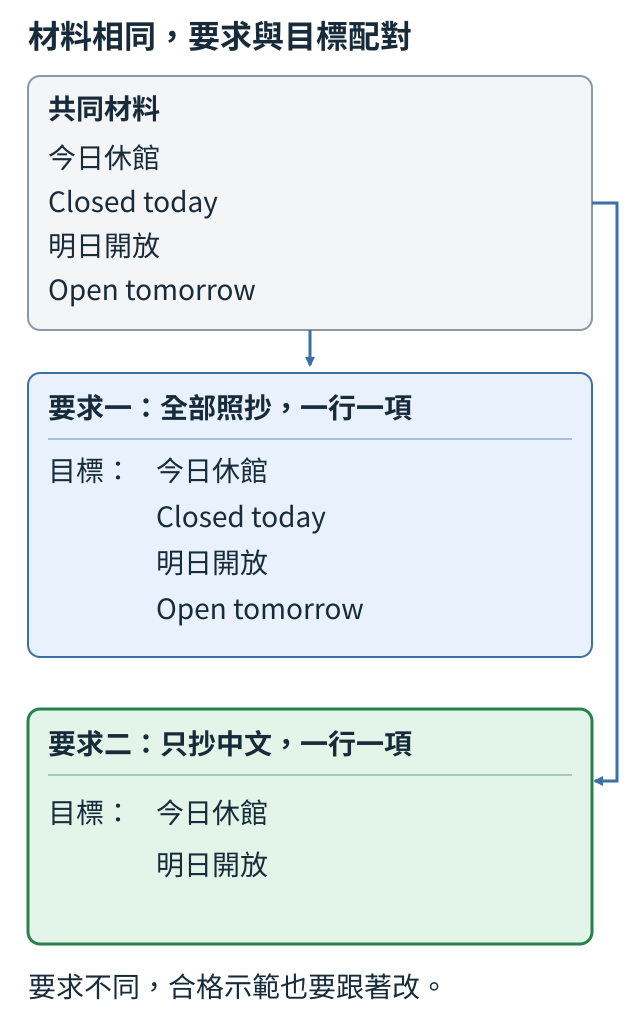

In [2]:
# @title 本節圖解
from IPython.display import SVG, display

display(SVG(filename=str(root / "course/figures/rewrite-08-new-8.15-request-target.svg")))

保留這種同材料對照，也能排除一個容易混淆的線索。假設訓練資料恰好「書店告示總是只抄中文，車站告示總是全部照抄」，模型可能靠題材猜該抄幾行。讓書店告示也出現在兩種要求下，就能清楚表達：決定這次交付物的，還有本次請求。這不是說每一種新句子都必須逐句教過；它是讓我們看得見這組示範究竟在教什麼。

現在再加第三個要求：「只抄中文，用只有text欄位的JSON物件，欄位值是依原順序排列的文字清單；不要在JSON外加字。」[8.5](https://birdhackor.github.io/tiny-perceptron-vlm/8.5.html)已看過JSON的欄位寫法，這次只把兩行中文放進同一個欄位。對應目標是：

```json
{"text":["今日休館","明日開放"]}
```

把上面兩行普通文字直接當成第三個要求的示範，會漏掉所要求的格式；換成JSON但放入英文，則漏掉指定範圍。整理資料時要逐筆核對「要求說了什麼，目標真的做了什麼」，不能只因三筆都含正確告示就認為可以互換。助手回答後也要在正確位置有結束目標，並沿用回答位置的有效監督；不要把EOS截掉後，還把這筆記成完整示範。

檢查新題時，可以保持告示不變，把「只抄中文」改問成「英文不要，兩條中文照原樣給我」。也可以換一份沒用來教模型的告示，再分別要求全部、中文或JSON。前者檢查新措辭，後者檢查新材料與要求的組合；同一告示的改寫題仍屬同一家族，不能一邊教、一邊當成沒見過材料的證據。

練習替同一告示加一筆「只抄英文，一行一項」的示範。應選第2、4列，仍保持原順序。再看第三個JSON目標：只把其要求中的「中文」改成「英文」，其他JSON格式規定不變。若欄位裡仍是兩句中文，這筆新資料在教什麼？先指出不一致，再改成真正執行要求的答案。

<details>
<summary>補充：示範資料的來源與泛化界線</summary>

[InstructGPT](https://arxiv.org/pdf/2203.02155v1)§3.1–3.2以期望行為的示範做SFT；[FLAN](https://arxiv.org/pdf/2109.01652v5)§2.1、§4.3討論自然語言指令與對應目標，§2.2另安排未訓練任務的評估。本節沿用這個資料關係，沒有宣稱所有新措辭都必須逐句有專用示範，也沒有保證一組示範足以教會任意格式。

EOS有效監督與首答案位置仍依[7.3](https://birdhackor.github.io/tiny-perceptron-vlm/7.3.html)、[7.4](https://birdhackor.github.io/tiny-perceptron-vlm/7.4.html)、[7.9](https://birdhackor.github.io/tiny-perceptron-vlm/7.9.html)安排。相關段落與適用界線見[指令遵循來源筆記](https://github.com/birdhackor/tiny-perceptron-vlm/blob/main/docs/course-revision-20261005/sources/instruction-following.md)。

</details>
